# Train and Export the RLHF Playground cVAE

This notebook runs the same training/export scripts as the local backend commands. It is meant for Google Colab, but it also works in Jupyter if you run it from the repo root.

Expected outputs:

- `backend_training/checkpoints/cvae.pt`
- `backend_training/checkpoints/recon_preview.png`
- `backend_training/checkpoints/sample_grid_digit7.png`
- `public/models/decoder.onnx`
- `public/models/decoder.onnx.data`
- `public/models/metadata.json`


## 1. Runtime Setup

In Colab, choose **Runtime > Change runtime type > T4 GPU** or another GPU runtime before running this notebook.

This notebook expects to run from the repo root. If you opened the notebook from outside the repo tree, copy or clone the repo into Colab first, then point `REPO_DIR` at that checkout.

In [4]:
from pathlib import Path
import os
import sys

# If auto-detection fails in Colab, set REPO_DIR manually to your repo checkout.
CANDIDATE_REPO_DIRS = [
    Path.cwd(),
    Path('/content/vaedemo'),
    Path('/content/drive/MyDrive/vaedemo'),
]

REPO_DIR = None
for candidate in CANDIDATE_REPO_DIRS:
    if (candidate / 'backend_training/train_cvae.py').exists():
        REPO_DIR = candidate
        break

if REPO_DIR is None:
    raise FileNotFoundError(
        'Could not find the repo root. Copy or clone the repo into Colab, then set REPO_DIR manually in this cell.'
    )

os.chdir(REPO_DIR)

print('Working directory:', Path.cwd())
print('Python:', sys.version)


Working directory: /content/vaedemo
Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


## 2. Install Python Dependencies

Colab usually already has PyTorch, but this keeps the export dependencies available too.

In [5]:
%pip install -q torch torchvision onnx onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 100.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 714.8/714.8 kB 58.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 20.7 MB/s eta 0:00:00


## 3. Verify Repo Files

These checks make sure the notebook is using the same implementation as the local commands.

In [6]:
required_files = [
    Path('backend_training/data/colored_mnist.py'),
    Path('backend_training/models/cvae.py'),
    Path('backend_training/train_cvae.py'),
    Path('backend_training/export_decoder.py'),
    Path('backend_training/sample_grid.py'),
]

missing = [str(path) for path in required_files if not path.exists()]
if missing:
    raise FileNotFoundError('Missing repo files: ' + ', '.join(missing))

print('All backend training files found.')


All backend training files found.


## 4. Train the cVAE

This uses the exact same script as local training. The defaults are `latent_dim=2` and `image_size=64`.

For a quick smoke test, set `EPOCHS = 1`. For a usable demo, start with `EPOCHS = 20`.

In [7]:
import torch

EPOCHS = 20
BATCH_SIZE = 256
NUM_WORKERS = 2
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

print('Device:', DEVICE)
!python backend_training/train_cvae.py --epochs {EPOCHS} --batch-size {BATCH_SIZE} --num-workers {NUM_WORKERS} --device {DEVICE}


Device: cuda
100% 9.91M/9.91M [00:00<00:00, 17.9MB/s]
100% 28.9k/28.9k [00:00<00:00, 481kB/s]
100% 1.65M/1.65M [00:00<00:00, 4.58MB/s]
100% 4.54k/4.54k [00:00<00:00, 6.40MB/s]
epoch 001 loss=0.19684 recon=0.19401 kl=2.83605
epoch 002 loss=0.07892 recon=0.07663 kl=2.29370
epoch 003 loss=0.07412 recon=0.07189 kl=2.22463
epoch 004 loss=0.06650 recon=0.06409 kl=2.40920
epoch 005 loss=0.06403 recon=0.06154 kl=2.48548
epoch 006 loss=0.06280 recon=0.06028 kl=2.52162
epoch 007 loss=0.06044 recon=0.05784 kl=2.59757
epoch 008 loss=0.05885 recon=0.05620 kl=2.64077
epoch 009 loss=0.05781 recon=0.05513 kl=2.67658
epoch 010 loss=0.05738 recon=0.05469 kl=2.69523
epoch 011 loss=0.05660 recon=0.05389 kl=2.71176
epoch 012 loss=0.05632 recon=0.05359 kl=2.72870
epoch 013 loss=0.05605 recon=0.05332 kl=2.73651
epoch 014 loss=0.05566 recon=0.05288 kl=2.77299
epoch 015 loss=0.05464 recon=0.05182 kl=2.81831
epoch 016 loss=0.05451 recon=0.05167 kl=2.83755
epoch 017 loss=0.05413 recon=0.05127 kl=2.85445
epoch 01

## 5. Export the Decoder for the Website

This writes the same frontend files used by the Vite app.

In [8]:
!python backend_training/export_decoder.py

/content/vaedemo/backend_training/export_decoder.py:37: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0503 19:35:33.352000 11518 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
[torch.onnx] Obtain model graph for `ConditionalDecoder([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ConditionalDecoder([...]` with `torch.export.export(...,

## 6. Sample a Latent Grid for Visual Inspection

This image is just for checking decoder quality before you use the website.

In [9]:
SAMPLE_DIGIT = 7
!python backend_training/sample_grid.py --digit {SAMPLE_DIGIT} --out backend_training/checkpoints/sample_grid_digit{SAMPLE_DIGIT}.png --device {DEVICE}


saved sample grid: backend_training/checkpoints/sample_grid_digit7.png


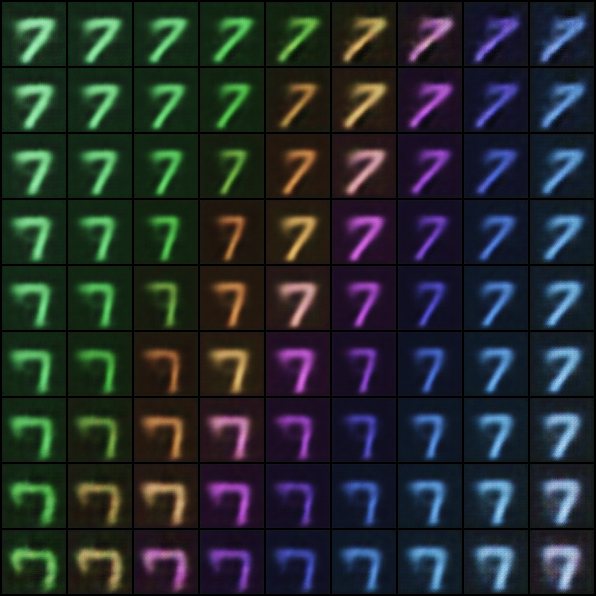

In [10]:
from IPython.display import Image, display

preview = Path(f'backend_training/checkpoints/sample_grid_digit{SAMPLE_DIGIT}.png')
if preview.exists():
    display(Image(filename=str(preview)))
else:
    print('Preview image not found:', preview)


## 7. Confirm Output Files

Copy `public/models/decoder.onnx`, `public/models/decoder.onnx.data`, and `public/models/metadata.json` back into the local repo if you trained in Colab.

Those three files are the handoff into the local RLHF demo. The browser keeps the decoder frozen and learns a reward model and latent policy from local preference clicks.

In [11]:
outputs = [
    Path('backend_training/checkpoints/cvae.pt'),
    Path('backend_training/checkpoints/recon_preview.png'),
    Path(f'backend_training/checkpoints/sample_grid_digit{SAMPLE_DIGIT}.png'),
    Path('public/models/decoder.onnx'),
    Path('public/models/decoder.onnx.data'),
    Path('public/models/metadata.json'),
]

for path in outputs:
    status = 'OK' if path.exists() else 'MISSING'
    size = path.stat().st_size if path.exists() else 0
    print(f'{status:7} {size:>12} bytes  {path}')


OK           5846907 bytes  backend_training/checkpoints/cvae.pt
OK             89539 bytes  backend_training/checkpoints/recon_preview.png
OK            522334 bytes  backend_training/checkpoints/sample_grid_digit7.png
OK              3657 bytes  public/models/decoder.onnx
OK           3014656 bytes  public/models/decoder.onnx.data
OK               169 bytes  public/models/metadata.json


## Optional: Zip the Website Model Files

This makes it easier to download the exact files needed by the frontend. In Colab, the next cell also triggers a browser download.

In [12]:
zip_path = Path('public/models/frontend_decoder_assets.zip')
!zip -j {zip_path} public/models/decoder.onnx public/models/decoder.onnx.data public/models/metadata.json
print(f'Created {zip_path}')

try:
    from google.colab import files
    files.download(str(zip_path))
except ImportError:
    print('Not running in Colab. Download the zip from the local filesystem if needed.')


  adding: decoder.onnx (deflated 56%)
  adding: decoder.onnx.data (deflated 9%)
  adding: metadata.json (deflated 38%)
Created public/models/frontend_decoder_assets.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [15]:
from google.colab import files
files.download('public/models/frontend_decoder_assets.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>